In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display
import numpy as np
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']


control_condition = 'wiii8'


df1 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/behaviour_detection.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/behaviour_detection.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/behaviour_detection.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/behaviour_detection.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/behaviour_detection.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

order = [control_condition] + [
    condition for condition in df['condition'].drop_duplicates().tolist()
    if condition != control_condition
]
palette = dict(zip(order, sns.color_palette('Set2', n_colors=len(order))))


df.columns

Index(['track_id', 'frame', 'instance_score', 'x_head', 'y_head', 'score_head',
       'x_body', 'y_body', 'score_body', 'x_tail',
       ...
       'is_stationary_large_bend', 'is_stationary_turn_related',
       'closest_node_node_other_id', 'closest_nodes',
       'closest_node_node_distance', 'head_nearest_id', 'closest_node_to_head',
       'head_distance', 'file', 'condition'],
      dtype='object', length=104)

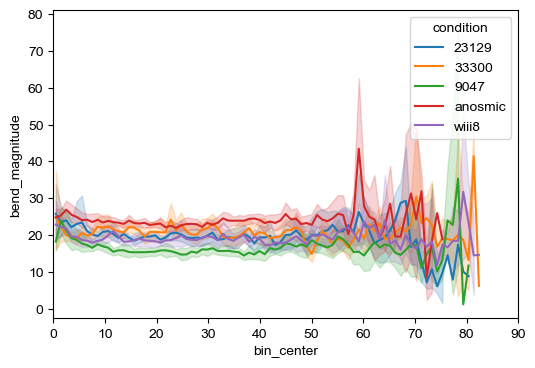

In [3]:
bins = np.linspace(0, 91, 91)  # 0 to 90 in 5 increments
df['bin'] = pd.cut(df['head_distance'], bins, include_lowest=True)
df['bin_center'] = df['bin'].apply(lambda x: x.mid)


grouped = df.groupby(['condition', 'file', 'bin_center']).agg({'bend_magnitude': 'mean'}).reset_index()

plt.figure(figsize=(6, 4))

sns.lineplot(data=grouped, x='bin_center', y='bend_magnitude', hue='condition')
plt.xlim(0,90)
plt.show()

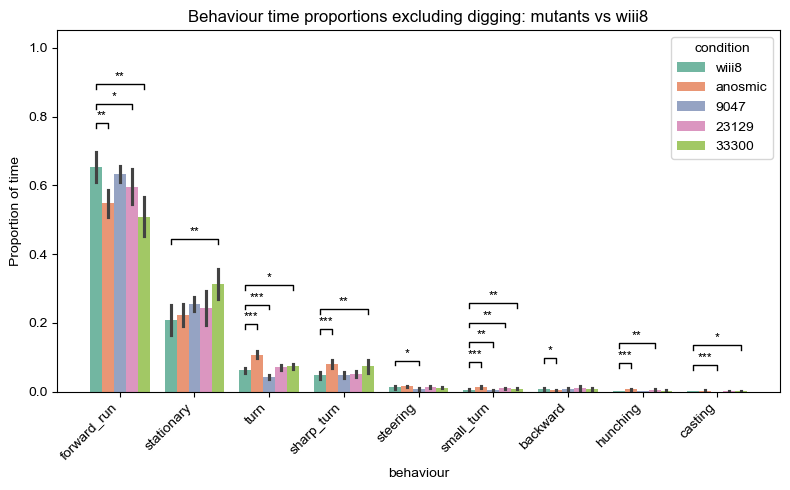

Mann-Whitney U tests: each condition compared with wiii8
Holm correction is applied across mutant comparisons within each behaviour.


,behaviour,control,condition,comparison,test,U,p_raw,n_control,n_condition,p_holm,stars
24,backward,wiii8,anosmic,anosmic vs wiii8,Mann-Whitney U,86.0,0.007285,10,10,0.029138,*
26,backward,wiii8,23129,23129 vs wiii8,Mann-Whitney U,29.0,0.121225,10,10,0.363674,ns
25,backward,wiii8,9047,9047 vs wiii8,Mann-Whitney U,35.0,0.273036,10,10,0.546073,ns
27,backward,wiii8,33300,33300 vs wiii8,Mann-Whitney U,41.0,0.520523,10,10,0.546073,ns
33,casting,wiii8,9047,9047 vs wiii8,Mann-Whitney U,100.0,0.000132,10,10,0.000527,***
35,casting,wiii8,33300,33300 vs wiii8,Mann-Whitney U,88.0,0.004586,10,10,0.013759,*
34,casting,wiii8,23129,23129 vs wiii8,Mann-Whitney U,75.0,0.064022,10,10,0.128044,ns
32,casting,wiii8,anosmic,anosmic vs wiii8,Mann-Whitney U,35.0,0.273036,10,10,0.273036,ns
0,forward_run,wiii8,anosmic,anosmic vs wiii8,Mann-Whitney U,96.0,0.000583,10,10,0.001759,**
3,forward_run,wiii8,33300,33300 vs wiii8,Mann-Whitney U,97.0,0.000440,10,10,0.001759,**


In [7]:
# Proportion of time in each behaviour, excluding digging, with Mann-Whitney tests versus wiii8.
# Each recording contributes one value per behaviour; missing behaviours are treated as zero time.
# Digging is removed before calculating both total time and behaviour-specific time.

time_df = df[df["behaviour"].astype(str).str.lower() != "digging"].copy()
# time_df = df.copy()

total_frames = (
    time_df.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

behaviour_frames = (
    time_df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

behaviour_order = (
    behaviour_frames.groupby("behaviour")["n_frames"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = total_frames[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(behaviour_frames, on=["file", "condition", "behaviour"], how="left")
    .merge(total_frames, on=["file", "condition"], how="left")
)
behaviour_prop["n_frames"] = behaviour_prop["n_frames"].fillna(0)
behaviour_prop["proportion"] = behaviour_prop["n_frames"] / behaviour_prop["total_frames"]

# Order by the final plotted value: overall mean proportion, highest to lowest.
behaviour_order = (
    behaviour_prop.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


pairwise_time_rows = []

for behaviour in behaviour_order:
    behaviour_data = behaviour_prop[behaviour_prop["behaviour"] == behaviour]
    control_values = behaviour_data.loc[
        behaviour_data["condition"] == control_condition,
        "proportion",
    ].dropna()

    comparisons = []
    raw_p_values = []

    for condition in order:
        if condition == control_condition:
            continue

        condition_values = behaviour_data.loc[
            behaviour_data["condition"] == condition,
            "proportion",
        ].dropna()

        if len(control_values) > 0 and len(condition_values) > 0:
            u_stat, p_raw = mannwhitneyu(
                control_values,
                condition_values,
                alternative="two-sided",
            )
        else:
            u_stat, p_raw = np.nan, np.nan

        comparisons.append({
            "behaviour": behaviour,
            "control": control_condition,
            "condition": condition,
            "comparison": f"{condition} vs {control_condition}",
            "test": "Mann-Whitney U",
            "U": u_stat,
            "p_raw": p_raw,
            "n_control": len(control_values),
            "n_condition": len(condition_values),
        })
        raw_p_values.append(p_raw)

    valid_p_values = [p_value for p_value in raw_p_values if pd.notna(p_value)]
    corrected_iter = iter(multipletests(valid_p_values, method="holm")[1]) if valid_p_values else iter([])

    for row in comparisons:
        row["p_holm"] = next(corrected_iter) if pd.notna(row["p_raw"]) else np.nan
        row["stars"] = p_to_stars(row["p_holm"])
        pairwise_time_rows.append(row)

pairwise_time_stats = pd.DataFrame(pairwise_time_rows)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=behaviour_prop,
    x="behaviour",
    y="proportion",
    hue="condition",
    errorbar="sd",
    palette=palette,
    hue_order=order,
    order=behaviour_order,
)

# Only annotate significant comparisons on the plot; keep ns values in the printed table.
plot_all_control_comparisons = False

if not pairwise_time_stats.empty:
    plot_pairs = pairwise_time_stats.copy()
    if not plot_all_control_comparisons:
        plot_pairs = plot_pairs[plot_pairs["p_holm"] < 0.05].copy()

    if not plot_pairs.empty:
        x_lookup = {behaviour: i for i, behaviour in enumerate(behaviour_order)}
        hue_offsets = {
            condition: (i - (len(order) - 1) / 2) * 0.8 / len(order)
            for i, condition in enumerate(order)
        }
        y_max = behaviour_prop["proportion"].max()
        y_step = max(y_max * 0.08, 0.02)

        for behaviour, behaviour_pairs in plot_pairs.groupby("behaviour", sort=False):
            behaviour_max = behaviour_prop.loc[
                behaviour_prop["behaviour"] == behaviour,
                "proportion",
            ].max()
            behaviour_pairs = behaviour_pairs.sort_values("condition", key=lambda s: s.map({c: i for i, c in enumerate(order)}))
            for level, (_, row) in enumerate(behaviour_pairs.iterrows()):
                x1 = x_lookup[behaviour] + hue_offsets[control_condition]
                x2 = x_lookup[behaviour] + hue_offsets[row["condition"]]
                y = behaviour_max + y_step * (level + 1)
                h = y_step * 0.25
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1)
                ax.text(
                    (x1 + x2) / 2,
                    y + h,
                    row["stars"],
                    ha="center",
                    va="bottom",
                    color="black",
                    fontsize=9,
                )

        max_annotations = plot_pairs.groupby("behaviour").size().max()
        ax.set_ylim(0, y_max + y_step * (max_annotations + 2))

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of time")
plt.title(f"Behaviour time proportions excluding digging: mutants vs {control_condition}")

plt.tight_layout()
plt.show()

print(f"Mann-Whitney U tests: each condition compared with {control_condition}")
print("Holm correction is applied across mutant comparisons within each behaviour.")
if pairwise_time_stats.empty:
    display(pd.DataFrame(columns=[
        "behaviour", "comparison", "test", "U", "p_raw", "p_holm", "stars", "n_control", "n_condition"
    ]))
else:
    display(pairwise_time_stats.sort_values(["behaviour", "p_holm"]))


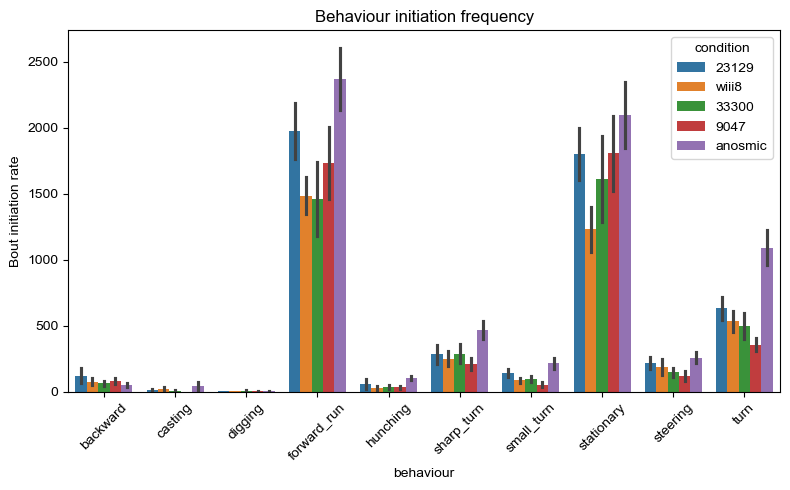

In [5]:
df = df.sort_values(["file", "track_id", "frame"]).copy()

df["prev_behaviour"] = df.groupby(["file", "track_id"])["behaviour"].shift()

df["is_initiation"] = df["behaviour"] != df["prev_behaviour"]

bout_counts = (
    df[df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=bout_counts,
    x="behaviour",
    y="n_bouts",
    hue="condition",
    errorbar="sd",
)

plt.xticks(rotation=45)
plt.ylabel("Bout initiation rate")
plt.title("Behaviour initiation frequency")

plt.tight_layout()
plt.show()

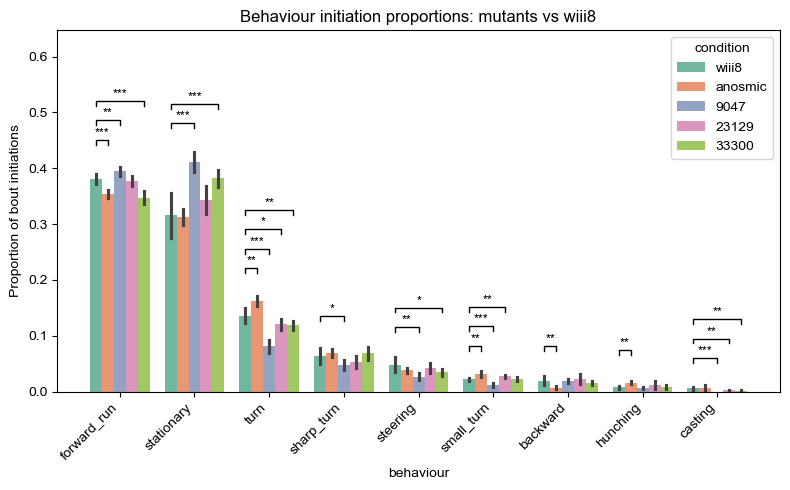

Mann-Whitney U tests: each condition compared with wiii8
Holm correction is applied across mutant comparisons within each behaviour.


,behaviour,control,condition,comparison,test,U,p_raw,n_control,n_condition,p_holm,stars
24,backward,wiii8,anosmic,anosmic vs wiii8,Mann-Whitney U,94.0,0.001008,10,10,0.004032,**
25,backward,wiii8,9047,9047 vs wiii8,Mann-Whitney U,49.0,0.969850,10,10,1.000000,ns
26,backward,wiii8,23129,23129 vs wiii8,Mann-Whitney U,43.0,0.623176,10,10,1.000000,ns
27,backward,wiii8,33300,33300 vs wiii8,Mann-Whitney U,63.0,0.344704,10,10,1.000000,ns
33,casting,wiii8,9047,9047 vs wiii8,Mann-Whitney U,100.0,0.000132,10,10,0.000527,***
35,casting,wiii8,33300,33300 vs wiii8,Mann-Whitney U,94.0,0.001008,10,10,0.003024,**
34,casting,wiii8,23129,23129 vs wiii8,Mann-Whitney U,91.0,0.002202,10,10,0.004404,**
32,casting,wiii8,anosmic,anosmic vs wiii8,Mann-Whitney U,48.0,0.909722,10,10,0.909722,ns
3,forward_run,wiii8,33300,33300 vs wiii8,Mann-Whitney U,100.0,0.000183,10,10,0.000731,***
0,forward_run,wiii8,anosmic,anosmic vs wiii8,Mann-Whitney U,99.0,0.000246,10,10,0.000738,***


In [6]:
# Proportion of bout initiations, excluding digging, with Mann-Whitney tests versus wiii8.
# Digging is removed before counting initiations, and track starts are excluded.

bout_df = df[df["behaviour"].astype(str).str.lower() != "digging"].copy()

bout_df = bout_df.sort_values(["file", "track_id", "frame"])
bout_df["prev_behaviour"] = bout_df.groupby(["file", "track_id"])["behaviour"].shift()
bout_df = bout_df[bout_df["prev_behaviour"].notna()].copy()
bout_df["is_initiation"] = bout_df["behaviour"] != bout_df["prev_behaviour"]

bout_counts_no_digging = (
    bout_df[bout_df["is_initiation"]]
    .groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_bouts")
)

behaviour_order = (
    bout_counts_no_digging.groupby("behaviour")["n_bouts"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

recordings = bout_counts_no_digging[["file", "condition"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

bout_prop = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(bout_counts_no_digging, on=["file", "condition", "behaviour"], how="left")
)
bout_prop["n_bouts"] = bout_prop["n_bouts"].fillna(0)
bout_prop["total_bouts"] = bout_prop.groupby(["file", "condition"])["n_bouts"].transform("sum")
bout_prop = bout_prop[bout_prop["total_bouts"] > 0].copy()
bout_prop["bout_initiation_proportion"] = bout_prop["n_bouts"] / bout_prop["total_bouts"]

# Order by the final plotted value: overall mean proportion, highest to lowest.
behaviour_order = (
    bout_prop.groupby("behaviour")["bout_initiation_proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


pairwise_rows = []

for behaviour in behaviour_order:
    behaviour_data = bout_prop[bout_prop["behaviour"] == behaviour]
    control_values = behaviour_data.loc[
        behaviour_data["condition"] == control_condition,
        "bout_initiation_proportion",
    ].dropna()

    comparisons = []
    raw_p_values = []

    for condition in order:
        if condition == control_condition:
            continue

        condition_values = behaviour_data.loc[
            behaviour_data["condition"] == condition,
            "bout_initiation_proportion",
        ].dropna()

        if len(control_values) > 0 and len(condition_values) > 0:
            u_stat, p_raw = mannwhitneyu(
                control_values,
                condition_values,
                alternative="two-sided",
            )
        else:
            u_stat, p_raw = np.nan, np.nan

        comparisons.append({
            "behaviour": behaviour,
            "control": control_condition,
            "condition": condition,
            "comparison": f"{condition} vs {control_condition}",
            "test": "Mann-Whitney U",
            "U": u_stat,
            "p_raw": p_raw,
            "n_control": len(control_values),
            "n_condition": len(condition_values),
        })
        raw_p_values.append(p_raw)

    valid_p_values = [p_value for p_value in raw_p_values if pd.notna(p_value)]
    corrected_iter = iter(multipletests(valid_p_values, method="holm")[1]) if valid_p_values else iter([])

    for row in comparisons:
        row["p_holm"] = next(corrected_iter) if pd.notna(row["p_raw"]) else np.nan
        row["stars"] = p_to_stars(row["p_holm"])
        pairwise_rows.append(row)

pairwise_stats = pd.DataFrame(pairwise_rows)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=bout_prop,
    x="behaviour",
    y="bout_initiation_proportion",
    hue="condition",
    errorbar="sd",
    palette=palette,
    hue_order=order,
    order=behaviour_order,
)

# Only annotate significant comparisons on the plot; keep ns values in the printed table.
plot_all_control_comparisons = False

if not pairwise_stats.empty:
    plot_pairs = pairwise_stats.copy()
    if not plot_all_control_comparisons:
        plot_pairs = plot_pairs[plot_pairs["p_holm"] < 0.05].copy()

    if not plot_pairs.empty:
        x_lookup = {behaviour: i for i, behaviour in enumerate(behaviour_order)}
        hue_offsets = {
            condition: (i - (len(order) - 1) / 2) * 0.8 / len(order)
            for i, condition in enumerate(order)
        }
        y_max = bout_prop["bout_initiation_proportion"].max()
        y_step = max(y_max * 0.08, 0.02)

        for behaviour, behaviour_pairs in plot_pairs.groupby("behaviour", sort=False):
            behaviour_max = bout_prop.loc[
                bout_prop["behaviour"] == behaviour,
                "bout_initiation_proportion",
            ].max()
            behaviour_pairs = behaviour_pairs.sort_values("condition", key=lambda s: s.map({c: i for i, c in enumerate(order)}))
            for level, (_, row) in enumerate(behaviour_pairs.iterrows()):
                x1 = x_lookup[behaviour] + hue_offsets[control_condition]
                x2 = x_lookup[behaviour] + hue_offsets[row["condition"]]
                y = behaviour_max + y_step * (level + 1)
                h = y_step * 0.25
                ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", linewidth=1)
                ax.text(
                    (x1 + x2) / 2,
                    y + h,
                    row["stars"],
                    ha="center",
                    va="bottom",
                    color="black",
                    fontsize=9,
                )

        max_annotations = plot_pairs.groupby("behaviour").size().max()
        ax.set_ylim(0, y_max + y_step * (max_annotations + 2))

plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion of bout initiations")
plt.title(f"Behaviour initiation proportions: mutants vs {control_condition}")

plt.tight_layout()
plt.show()

print(f"Mann-Whitney U tests: each condition compared with {control_condition}")
print("Holm correction is applied across mutant comparisons within each behaviour.")
if pairwise_stats.empty:
    display(pd.DataFrame(columns=[
        "behaviour", "comparison", "test", "U", "p_raw", "p_holm", "stars", "n_control", "n_condition"
    ]))
else:
    display(pairwise_stats.sort_values(["behaviour", "p_holm"]))

